In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("PS_20174392719_1491204439457_log.csv")

In [29]:
df.shape

(6362620, 11)

In [30]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [32]:
df.isnull()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
6362615,False,False,False,False,False,False,False,False,False,False,False
6362616,False,False,False,False,False,False,False,False,False,False,False
6362617,False,False,False,False,False,False,False,False,False,False,False
6362618,False,False,False,False,False,False,False,False,False,False,False


In [33]:
print(df['isFraud'].value_counts())
print("\nFraud percentage:", round(df['isFraud'].mean() * 100, 3), "%")

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud percentage: 0.129 %


In [34]:
print(df.groupby('type')['isFraud'].sum())

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64


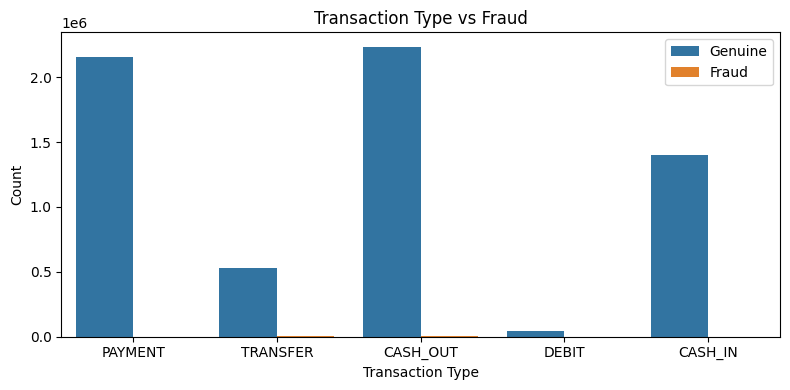

In [35]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='type', hue='isFraud')
plt.title('Transaction Type vs Fraud')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.legend(labels=['Genuine', 'Fraud'])
plt.tight_layout()
plt.show()

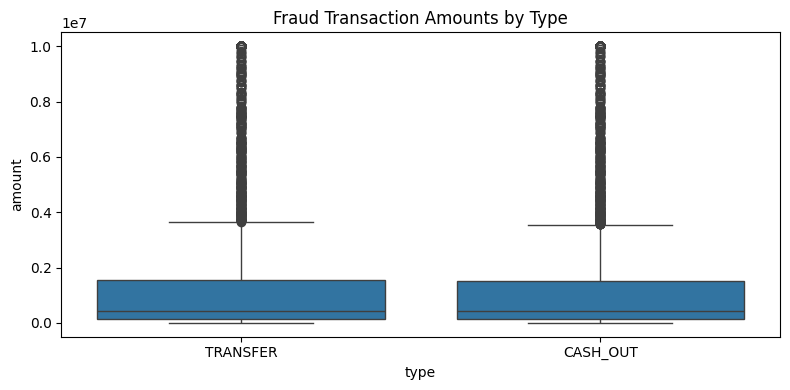

In [36]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df[df['isFraud']==1], x='type', y='amount')
plt.title('Fraud Transaction Amounts by Type')
plt.tight_layout()
plt.show()

In [37]:
# Keep only TRANSFER and CASH_OUT (only types with fraud)
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]
print("Shape after filtering:", df.shape)

# Feature 1: transaction type encoded
df['type_encoded'] = (df['type'] == 'TRANSFER').astype(int)

# Feature 2: odd hour flag (midnight to 6am = suspicious)
df['is_odd_hour'] = (df['step'] % 24 < 6).astype(int)

# Feature 3: balance wiped out after transaction
df['balance_wiped'] = (df['newbalanceOrig'] == 0).astype(int)

# Feature 4: balance difference
df['balance_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']

# Feature 5: large transaction flag (above 75th percentile)
threshold = df['amount'].quantile(0.75)
df['is_large_transaction'] = (df['amount'] > threshold).astype(int)

# Feature 6: destination balance unchanged after receiving money (fraud signal)
df['dest_balance_unchanged'] = (df['oldbalanceDest'] == df['newbalanceDest']).astype(int)

print("\nNew columns added:")
print(df.columns.tolist())

Shape after filtering: (2770409, 11)

New columns added:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'type_encoded', 'is_odd_hour', 'balance_wiped', 'balance_diff', 'is_large_transaction', 'dest_balance_unchanged']


In [38]:
features = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'type_encoded',
    'is_odd_hour',
    'balance_wiped',
    'balance_diff',
    'is_large_transaction',
    'dest_balance_unchanged'
]

X = df[features]
y = df['isFraud']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFraud cases:", y.sum())
print("Genuine cases:", (y==0).sum())

X shape: (2770409, 11)
y shape: (2770409,)

Fraud cases: 8213
Genuine cases: 2762196


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y,  # keeps fraud ratio same in both splits
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nFraud in train:", y_train.sum())
print("Fraud in test:", y_test.sum())

X_train shape: (2216327, 11)
X_test shape: (554082, 11)

Fraud in train: 6570
Fraud in test: 1643


In [40]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", X_train.shape, "| Fraud:", y_train.sum())
print("After SMOTE:", X_train_res.shape, "| Fraud:", y_train_res.sum())


Before SMOTE: (2216327, 11) | Fraud: 6570
After SMOTE: (4419514, 11) | Fraud: 2209757


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("Scaling done")

Scaling done


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_res)

lr_preds = lr_model.predict(X_test_scaled)
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    552439
           1       0.12      0.96      0.22      1643

    accuracy                           0.98    554082
   macro avg       0.56      0.97      0.60    554082
weighted avg       1.00      0.98      0.99    554082



In [ ]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(lr_model, '../models/logistic_regression.pkl')
joblib.dump(rf_model, '../models/random_forest.pkl')
joblib.dump(xgb_model, '../models/xgboost.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("All models saved successfully:")
print(os.listdir('../models'))

All models saved successfully:
['logistic_regression.pkl', 'random_forest.pkl', 'scaler.pkl', 'xgboost.pkl']


In [ ]:
print(dir())

['In', 'LogisticRegression', 'Out', 'RandomForestClassifier', 'SMOTE', 'StandardScaler', 'X', 'X_test', 'X_test_scaled', 'X_train', 'X_train_res', 'X_train_scaled', '_', '_4', '_5', '_7', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'classification_report', 'confusion_matrix', 'df', 'exit', 'features', 'get_ipython', 'joblib', 'lr_model', 'lr_preds', 'np', 'open', 'os', 'pd', 'plt', 'quit', 'rf_model', 'rf_small', 'rf_small_preds', 'scaler', 'size', 'sm', 'sns', 'threshold', 'train_test_split', 'y', 'y_test', 'y_train', 'y_train_res']


In [ ]:
print(dir())

['In', 'LogisticRegression', 'Out', 'RandomForestClassifier', 'SMOTE', 'StandardScaler', 'X', 'X_test', 'X_test_scaled', 'X_train', 'X_train_res', 'X_train_scaled', '_', '_4', '_5', '_7', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'classification_report', 'confusion_matrix', 'df', 'exit', 'features', 'get_ipython', 'joblib', 'lr_model', 'lr_preds', 'np', 'open', 'os', 'pd', 'plt', 'quit', 'rf_model', 'rf_small', 'rf_small_preds', 'scaler', 'size', 'sm', 'sns', 'threshold', 'train_test_split', 'y', 'y_test', 'y_train', 'y_train_res']


In [ ]:
print(dir())

['In', 'LogisticRegression', 'Out', 'RandomForestClassifier', 'SMOTE', 'StandardScaler', 'X', 'X_test', 'X_test_scaled', 'X_train', 'X_train_res', 'X_train_scaled', '_', '_4', '_5', '_7', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'classification_report', 'confusion_matrix', 'df', 'exit', 'features', 'get_ipython', 'joblib', 'lr_model', 'lr_preds', 'np', 'open', 'os', 'pd', 'plt', 'quit', 'rf_model', 'rf_small', 'rf_small_preds', 'scaler', 'size', 'sm', 'sns', 'threshold', 'train_test_split', 'y', 'y_test', 'y_train', 'y_train_res']


In [ ]:
print(dir())

['In', 'LogisticRegression', 'Out', 'RandomForestClassifier', 'SMOTE', 'StandardScaler', 'X', 'X_test', 'X_test_scaled', 'X_train', 'X_train_res', 'X_train_scaled', '_', '_4', '_5', '_7', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'classification_report', 'confusion_matrix', 'df', 'exit', 'features', 'get_ipython', 'joblib', 'lr_model', 'lr_preds', 'np', 'open', 'os', 'pd', 'plt', 'quit', 'rf_model', 'rf_small', 'rf_small_preds', 'scaler', 'size', 'sm', 'sns', 'threshold', 'train_test_split', 'y', 'y_test', 'y_train', 'y_train_res']


In [ ]:
print(dir())

['In', 'LogisticRegression', 'Out', 'RandomForestClassifier', 'SMOTE', 'StandardScaler', 'X', 'X_test', 'X_test_scaled', 'X_train', 'X_train_res', 'X_train_scaled', '_', '_4', '_5', '_7', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'classification_report', 'confusion_matrix', 'df', 'exit', 'features', 'get_ipython', 'joblib', 'lr_model', 'lr_preds', 'np', 'open', 'os', 'pd', 'plt', 'quit', 'rf_model', 'rf_small', 'rf_small_preds', 'scaler', 'size', 'sm', 'sns', 'threshold', 'train_test_split', 'y', 'y_test', 'y_train', 'y_train_res']


C:\Users\kusha\AppData\Local\Temp\ipykernel_11540\3458582877.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance, x='Importance', y='Feature', palette='viridis')


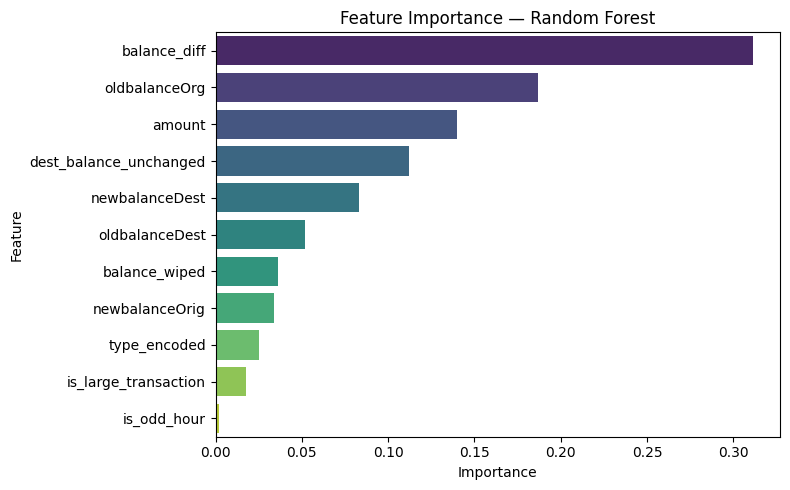

               Feature  Importance
          balance_diff    0.311532
         oldbalanceOrg    0.187083
                amount    0.139829
dest_balance_unchanged    0.111875
        newbalanceDest    0.083103
        oldbalanceDest    0.052005
         balance_wiped    0.036237
        newbalanceOrig    0.033728
          type_encoded    0.025085
  is_large_transaction    0.017679
           is_odd_hour    0.001844


In [ ]:
import matplotlib.pyplot as plt

feat_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

print(feat_importance.to_string(index=False))

In [ ]:
import os
print(os.getcwd())

c:\Users\kusha\OneDrive\Desktop\upi-fraud-detection


In [ ]:
from xgboost import XGBClassifier

# Retrain good random forest
rf_final = RandomForestClassifier(
    n_estimators=30,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train_scaled, y_train_res)

# Retrain XGBoost
xgb_final = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)
xgb_final.fit(X_train_scaled, y_train_res)

# Save all
joblib.dump(lr_model, 'models/logistic_regression.pkl')
joblib.dump(rf_final, 'models/random_forest.pkl', compress=3)
joblib.dump(xgb_final, 'models/xgboost.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / (1024*1024)
    print(f"{f}: {size:.2f} MB")

logistic_regression.pkl: 0.00 MB
random_forest.pkl: 8.36 MB
scaler.pkl: 0.00 MB
xgboost.pkl: 0.38 MB


In [ ]:
print(dir())

['In', 'LogisticRegression', 'Out', 'RandomForestClassifier', 'SMOTE', 'StandardScaler', 'X', 'X_test', 'X_test_scaled', 'X_train', 'X_train_res', 'X_train_scaled', '_', '_4', '_5', '_7', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'classification_report', 'confusion_matrix', 'df', 'exit', 'features', 'get_ipython', 'joblib', 'lr_model', 'lr_preds', 'np', 'open', 'os', 'pd', 'plt', 'quit', 'rf_model', 'rf_small', 'rf_small_preds', 'scaler', 'size', 'sm', 'sns', 'threshold', 'train_test_split', 'y', 'y_test', 'y_train', 'y_train_res']
